In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [2]:
df = pd.read_csv('../data/dataset.csv', sep=';')
print("Shape:", df.shape)
print("\nKolom:", df.columns.tolist())
df.head()

Shape: (4424, 37)

Kolom: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'G

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
print("=== INFO DATASET ===")
print(df.info())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== STATISTIK DASAR ===")
df.describe()

=== INFO DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification         

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


=== DISTRIBUSI TARGET ===
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


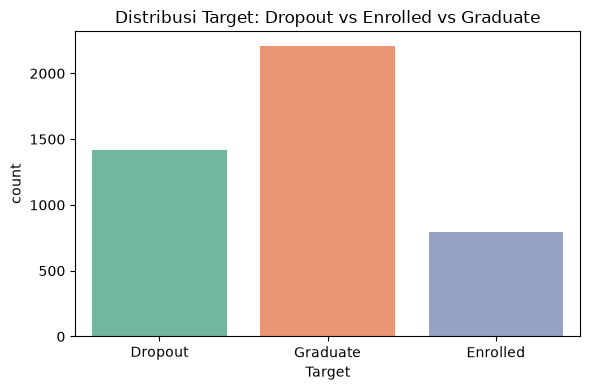

In [4]:
print("=== DISTRIBUSI TARGET ===")
print(df['Target'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='Target', data=df, palette='Set2')
plt.title('Distribusi Target: Dropout vs Enrolled vs Graduate')
plt.tight_layout()
plt.savefig('../data/plot_target.png')
plt.show()

In [5]:
# Fix nama kolom yang ada tab character
df.columns = df.columns.str.strip()

# Cek target
print("Nilai unik Target:", df['Target'].unique())
print(df['Target'].value_counts())

# Encode target: Dropout=0, Enrolled=1, Graduate=2
label_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Target'] = df['Target'].map(label_map)

print("\nSetelah encoding:")
print(df['Target'].value_counts())

Nilai unik Target: <ArrowStringArray>
['Dropout', 'Graduate', 'Enrolled']
Length: 3, dtype: str
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Setelah encoding:
Target
2    2209
0    1421
1     794
Name: count, dtype: int64


In [6]:
# Rasio kelulusan semester 1
# Fitur baru: seberapa efisien mahasiswa menyelesaikan SKS yang diambil
df['approval_rate_sem1'] = df['Curricular units 1st sem (approved)'] / (
    df['Curricular units 1st sem (enrolled)'].replace(0, 1))

# Rasio kelulusan semester 2
df['approval_rate_sem2'] = df['Curricular units 2nd sem (approved)'] / (
    df['Curricular units 2nd sem (enrolled)'].replace(0, 1))

# Tren nilai: positif = mahasiswa membaik, negatif = memburuk
df['grade_trend'] = (df['Curricular units 2nd sem (grade)'] - 
                     df['Curricular units 1st sem (grade)'])

print("✅ Feature engineering selesai!")
print(f"Total fitur sekarang: {df.shape[1]} kolom")
print("\nPreview fitur baru:")
print(df[['approval_rate_sem1', 'approval_rate_sem2', 'grade_trend']].describe().round(3))

✅ Feature engineering selesai!
Total fitur sekarang: 40 kolom

Preview fitur baru:
       approval_rate_sem1  approval_rate_sem2  grade_trend
count            4424.000            4424.000     4424.000
mean                0.698               0.660       -0.411
std                 0.365               0.383        2.890
min                 0.000               0.000      -16.143
25%                 0.500               0.400       -0.600
50%                 0.833               0.833        0.000
75%                 1.000               1.000        0.452
max                 1.000               1.000       16.000


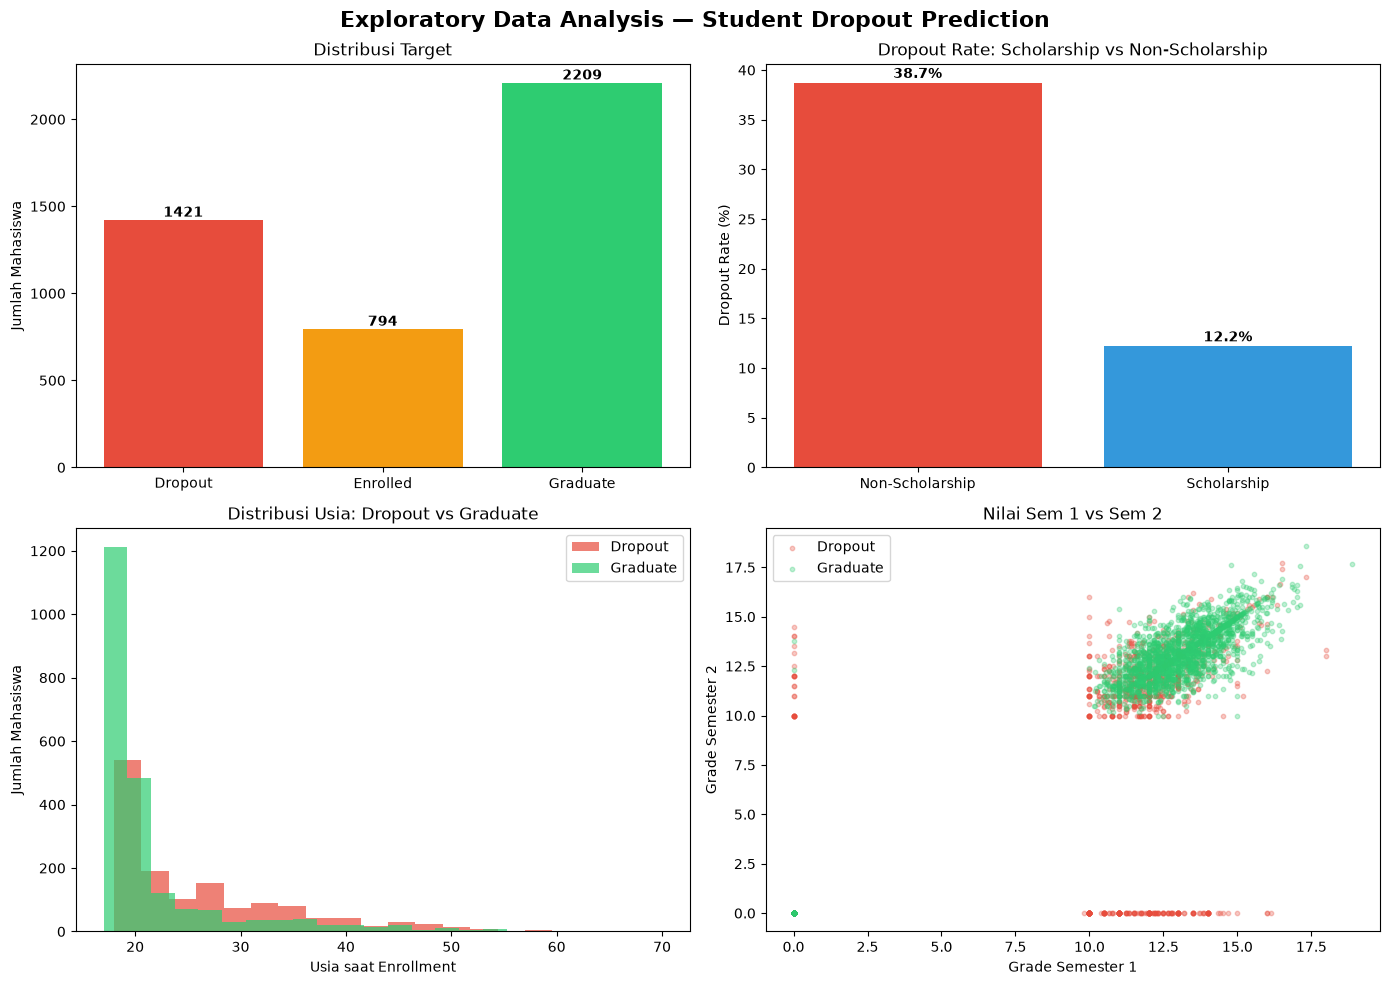

✅ EDA plots tersimpan!


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis — Student Dropout Prediction', 
             fontsize=16, fontweight='bold')

# Plot 1: Distribusi Target
target_labels = ['Dropout', 'Enrolled', 'Graduate']
target_counts = df['Target'].value_counts().sort_index()
axes[0,0].bar(target_labels, target_counts.values, 
              color=['#e74c3c', '#f39c12', '#2ecc71'])
axes[0,0].set_title('Distribusi Target')
axes[0,0].set_ylabel('Jumlah Mahasiswa')
for i, v in enumerate(target_counts.values):
    axes[0,0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Plot 2: Dropout Rate berdasarkan Scholarship
scholarship_dropout = df.groupby('Scholarship holder')['Target'].apply(
    lambda x: (x == 0).sum() / len(x) * 100
)
axes[0,1].bar(['Non-Scholarship', 'Scholarship'], 
              scholarship_dropout.values, 
              color=['#e74c3c', '#3498db'])
axes[0,1].set_title('Dropout Rate: Scholarship vs Non-Scholarship')
axes[0,1].set_ylabel('Dropout Rate (%)')
for i, v in enumerate(scholarship_dropout.values):
    axes[0,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 3: Distribusi Usia saat Enrollment
axes[1,0].hist(df[df['Target']==0]['Age at enrollment'], 
               bins=20, alpha=0.7, label='Dropout', color='#e74c3c')
axes[1,0].hist(df[df['Target']==2]['Age at enrollment'], 
               bins=20, alpha=0.7, label='Graduate', color='#2ecc71')
axes[1,0].set_title('Distribusi Usia: Dropout vs Graduate')
axes[1,0].set_xlabel('Usia saat Enrollment')
axes[1,0].set_ylabel('Jumlah Mahasiswa')
axes[1,0].legend()

# Plot 4: Nilai Semester 1 vs Semester 2
axes[1,1].scatter(
    df[df['Target']==0]['Curricular units 1st sem (grade)'],
    df[df['Target']==0]['Curricular units 2nd sem (grade)'],
    alpha=0.3, label='Dropout', color='#e74c3c', s=10
)
axes[1,1].scatter(
    df[df['Target']==2]['Curricular units 1st sem (grade)'],
    df[df['Target']==2]['Curricular units 2nd sem (grade)'],
    alpha=0.3, label='Graduate', color='#2ecc71', s=10
)
axes[1,1].set_title('Nilai Sem 1 vs Sem 2')
axes[1,1].set_xlabel('Grade Semester 1')
axes[1,1].set_ylabel('Grade Semester 2')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../data/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots tersimpan!")

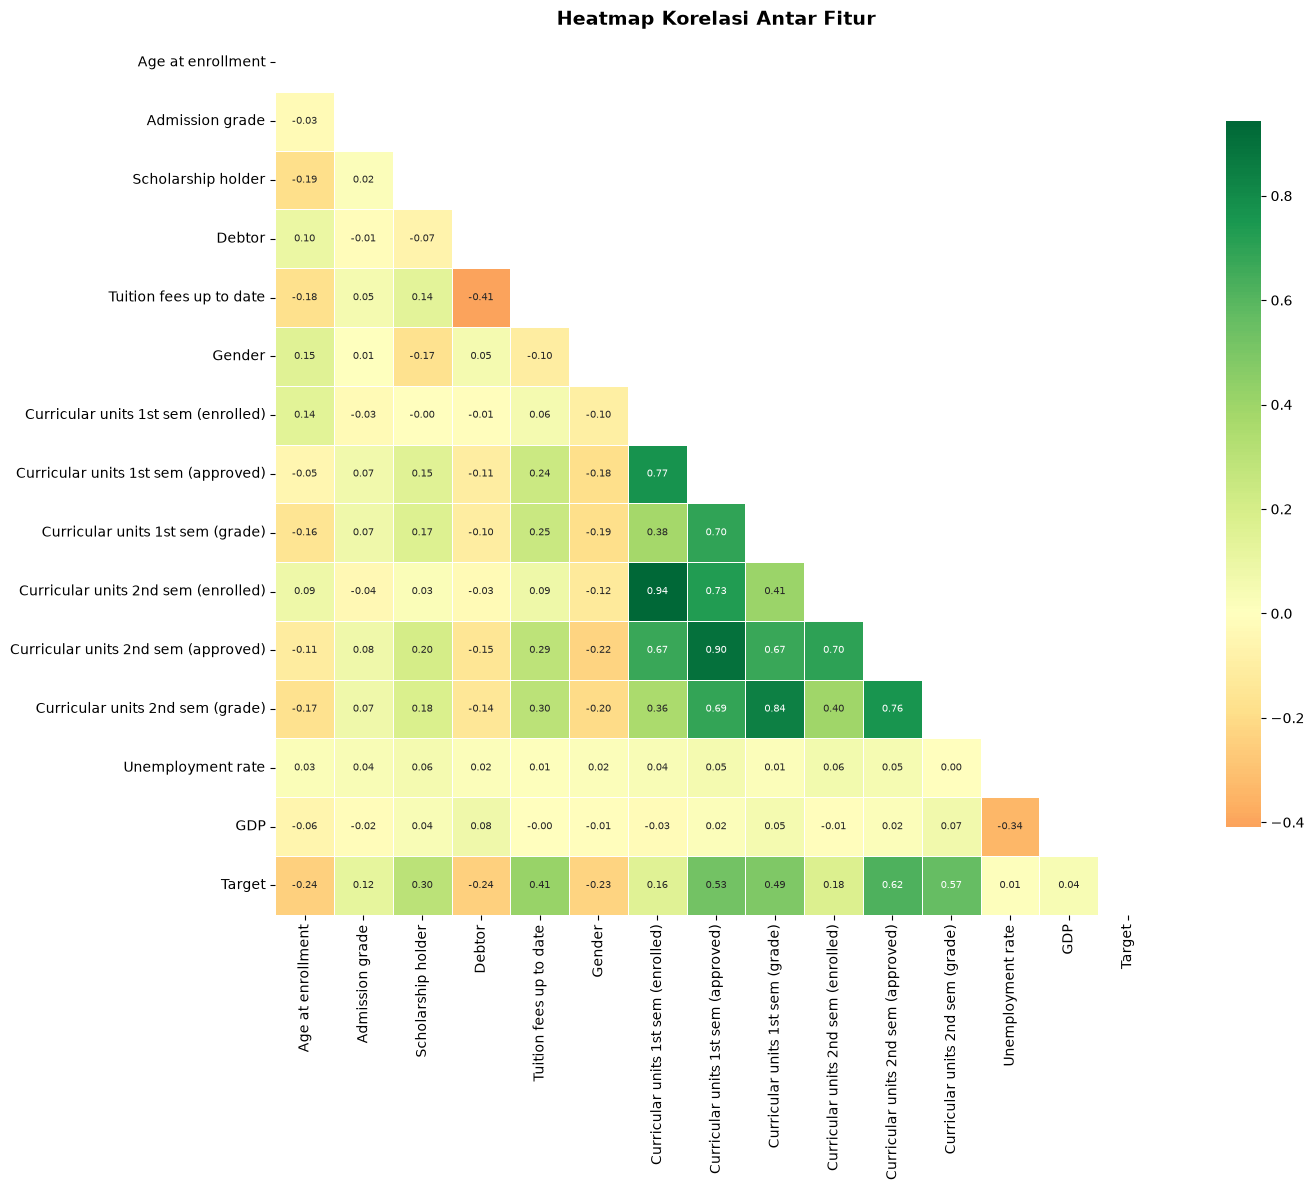

✅ Heatmap tersimpan!


In [8]:
plt.figure(figsize=(16, 12))

# Pilih fitur paling relevan untuk korelasi
key_features = [
    'Age at enrollment', 'Admission grade', 'Scholarship holder',
    'Debtor', 'Tuition fees up to date', 'Gender',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'GDP', 'Target'
]

corr_matrix = df[key_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7})

plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap tersimpan!")

In [9]:
# Pisahkan X (fitur) dan y (target)
X = df.drop('Target', axis=1)
y = df['Target']

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nContoh nilai y:", y.value_counts())

Shape X: (4424, 39)
Shape y: (4424,)

Contoh nilai y: Target
2    2209
0    1421
1     794
Name: count, dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # biar hasil reproducible
    stratify=y          # proporsi kelas harus sama di train & test
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("\nDistribusi kelas di train:")
print(y_train.value_counts())
print("\nDistribusi kelas di test:")
print(y_test.value_counts())

Ukuran X_train: (3539, 39)
Ukuran X_test: (885, 39)

Distribusi kelas di train:
Target
2    1767
0    1137
1     635
Name: count, dtype: int64

Distribusi kelas di test:
Target
2    442
0    284
1    159
Name: count, dtype: int64


In [11]:
# fit scaler hanya di train data, bukan seluruh dataset
# Kalau fit di seluruh data = data leakage!

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)    # fit + transform
X_test_scaled = scaler.transform(X_test)          # transform saja

print("✅ Scaling selesai!")
print("Contoh nilai sebelum scaling:", X_train.iloc[0, :3].values)
print("Contoh nilai setelah scaling:", X_train_scaled[0, :3])

✅ Scaling selesai!
Contoh nilai sebelum scaling: [ 1. 43.  1.]
Contoh nilai setelah scaling: [-0.29202044  1.39202754 -0.5562293 ]


In [12]:
# Simpan scaler sekarang karena akan dibutuhkan nanti di Streamlit
joblib.dump(scaler, '../model/scaler.pkl')
print("✅ Scaler tersimpan di ../model/scaler.pkl")

✅ Scaler tersimpan di ../model/scaler.pkl


In [13]:
from sklearn.linear_model import LogisticRegression

print("=" * 50)
print("MODEL 1: LOGISTIC REGRESSION")
print("=" * 50)

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

print("\n📊 Classification Report:")
print(classification_report(y_test, lr_pred, 
      target_names=['Dropout', 'Enrolled', 'Graduate']))

# Simpan model
joblib.dump(lr_model, '../model/logistic_model.pkl')
print("✅ Logistic Regression model tersimpan!")

MODEL 1: LOGISTIC REGRESSION

📊 Classification Report:
              precision    recall  f1-score   support

     Dropout       0.78      0.77      0.78       284
    Enrolled       0.52      0.31      0.39       159
    Graduate       0.81      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.70      0.67      0.68       885
weighted avg       0.75      0.77      0.75       885

✅ Logistic Regression model tersimpan!


MODEL 2: RANDOM FOREST

📊 Classification Report:
              precision    recall  f1-score   support

     Dropout       0.81      0.77      0.79       284
    Enrolled       0.59      0.38      0.46       159
    Graduate       0.81      0.93      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.70      0.71       885
weighted avg       0.77      0.78      0.77       885



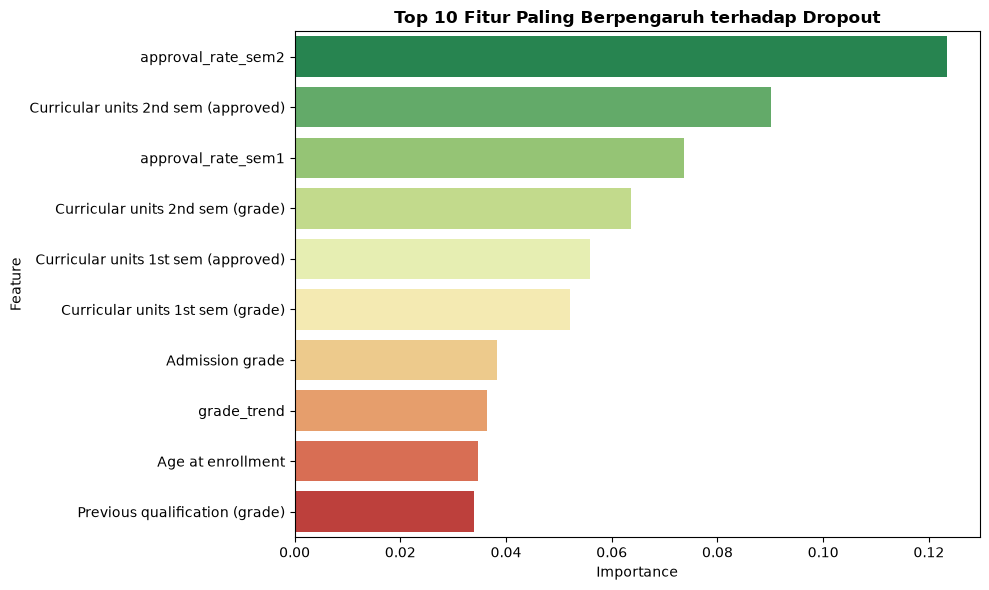


🔍 Top 10 Fitur Terpenting:
                            Feature  Importance
                 approval_rate_sem2    0.123492
Curricular units 2nd sem (approved)    0.090032
                 approval_rate_sem1    0.073660
   Curricular units 2nd sem (grade)    0.063598
Curricular units 1st sem (approved)    0.055810
   Curricular units 1st sem (grade)    0.052067
                    Admission grade    0.038336
                        grade_trend    0.036435
                  Age at enrollment    0.034737
     Previous qualification (grade)    0.034012

✅ Random Forest model tersimpan!


In [14]:
from sklearn.ensemble import RandomForestClassifier

print("=" * 50)
print("MODEL 2: RANDOM FOREST")
print("=" * 50)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

print("\n📊 Classification Report:")
print(classification_report(y_test, rf_pred,
      target_names=['Dropout', 'Enrolled', 'Graduate']))

# Feature importance — ini yang bikin proyekmu stand out
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, 
            palette='RdYlGn_r')
plt.title('Top 10 Fitur Paling Berpengaruh terhadap Dropout', 
          fontweight='bold')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()

print("\n🔍 Top 10 Fitur Terpenting:")
print(feature_importance.to_string(index=False))

# Simpan model
joblib.dump(rf_model, '../model/random_forest_model.pkl')
print("\n✅ Random Forest model tersimpan!")

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("=" * 50)
print("MODEL 3: NEURAL NETWORK (KERAS)")
print("=" * 50)

# Arsitektur Neural Network
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    
    layers.Dense(32, activation='relu'),
    
    layers.Dense(3, activation='softmax')  # 3 kelas output
])

nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

MODEL 3: NEURAL NETWORK (KERAS)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,555 (60.76 KB)

 Trainable params: 15,555 (60.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6747 - loss: 0.7914 - val_accuracy: 0.7797 - val_loss: 0.5748
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7443 - loss: 0.6341 - val_accuracy: 0.7768 - val_loss: 0.5589
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7587 - loss: 0.6004 - val_accuracy: 0.7768 - val_loss: 0.5496
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7598 - loss: 0.5757 - val_accuracy: 0.7797 - val_loss: 0.5500
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7736 - loss: 0.5667 - val_accuracy: 0.7740 - val_loss: 0.5466
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7750 - loss: 0.5555 - val_accuracy: 0.7712 - val_loss: 0.5558
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7715 - loss: 0.5528 - val_accuracy: 0.7768 - val_loss: 0.5483
Epoch 8/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7866 - loss: 0.5414 - val_accuracy: 0.7825 - val_loss:

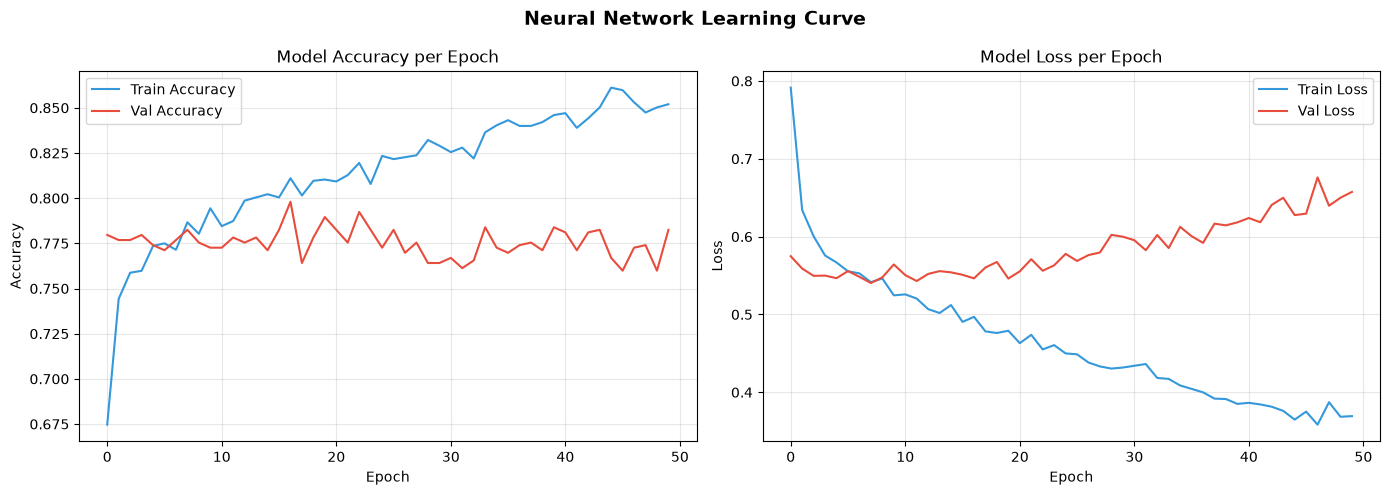

✅ Neural Network model tersimpan!


In [16]:
# Training
history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluasi
nn_pred = np.argmax(nn_model.predict(X_test_scaled), axis=1)

print("\n📊 Classification Report:")
print(classification_report(y_test, nn_pred,
      target_names=['Dropout', 'Enrolled', 'Graduate']))

# Plot Learning Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='#3498db')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='#e74c3c')
axes[0].set_title('Model Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss', color='#3498db')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c')
axes[1].set_title('Model Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Neural Network Learning Curve', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/learning_curve.png', dpi=150)
plt.show()

# Simpan model Neural Network
nn_model.save('../model/neural_network_model.keras')
print("✅ Neural Network model tersimpan!")

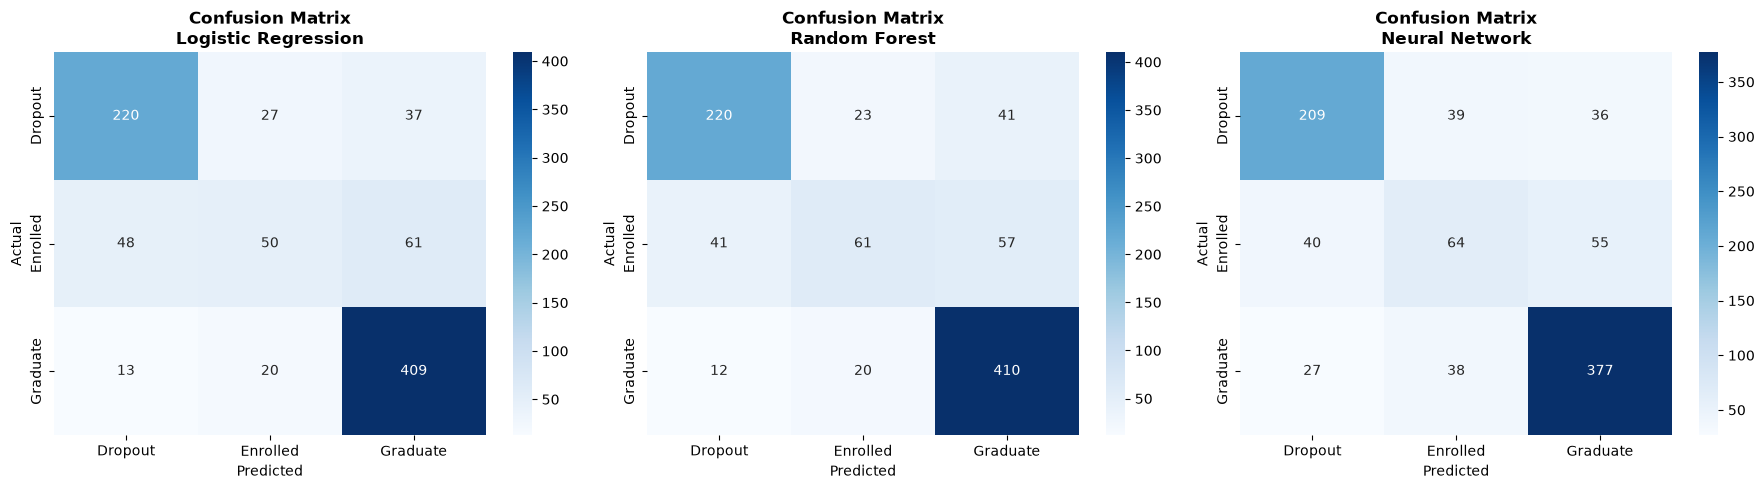

✅ Confusion matrices tersimpan!


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['Dropout', 'Enrolled', 'Graduate']
models_results = [
    ('Logistic Regression', lr_pred),
    ('Random Forest', rf_pred),
    ('Neural Network', nn_pred)
]

for ax, (name, pred) in zip(axes, models_results):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'Confusion Matrix\n{name}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../data/confusion_matrices.png', dpi=150)
plt.show()
print("✅ Confusion matrices tersimpan!")

In [18]:
from sklearn.metrics import accuracy_score, f1_score

results = {
    'Model': ['Logistic Regression', 'Random Forest', 'Neural Network'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, nn_pred)
    ],
    'F1-Score (Macro)': [
        f1_score(y_test, lr_pred, average='macro'),
        f1_score(y_test, rf_pred, average='macro'),
        f1_score(y_test, nn_pred, average='macro')
    ],
    'F1-Score (Weighted)': [
        f1_score(y_test, lr_pred, average='weighted'),
        f1_score(y_test, rf_pred, average='weighted'),
        f1_score(y_test, nn_pred, average='weighted')
    ]
}

results_df = pd.DataFrame(results)
results_df['Accuracy'] = results_df['Accuracy'].apply(lambda x: f'{x*100:.2f}%')
results_df['F1-Score (Macro)'] = results_df['F1-Score (Macro)'].apply(lambda x: f'{x*100:.2f}%')
results_df['F1-Score (Weighted)'] = results_df['F1-Score (Weighted)'].apply(lambda x: f'{x*100:.2f}%')

print("=" * 60)
print("📊 PERBANDINGAN PERFORMA KETIGA MODEL")
print("=" * 60)
print(results_df.to_string(index=False))
print("\n✅ Model terbaik siap digunakan untuk deployment!")

📊 PERBANDINGAN PERFORMA KETIGA MODEL
              Model Accuracy F1-Score (Macro) F1-Score (Weighted)
Logistic Regression   76.72%           67.71%              75.06%
      Random Forest   78.08%           70.57%              76.79%
     Neural Network   73.45%           66.72%              73.00%

✅ Model terbaik siap digunakan untuk deployment!
